In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from sklearn.metrics import accuracy_score


In [ ]:
from numpy.random import random_integers
X , Y= make_blobs(n_samples=1000 , n_features=2 , centers=4 ,cluster_std=1.5 ,random_state=42 )

x_blob = torch.from_numpy(X).type(torch.float)
y_blob = torch.from_numpy(Y).type(torch.LongTensor)

X_train  , X_test , Y_train ,Y_test = train_test_split(x_blob , y_blob, train_size=0.8, random_state=42)
X_train.shape , X_test.shape , Y_train.shape , Y_test.shape


(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

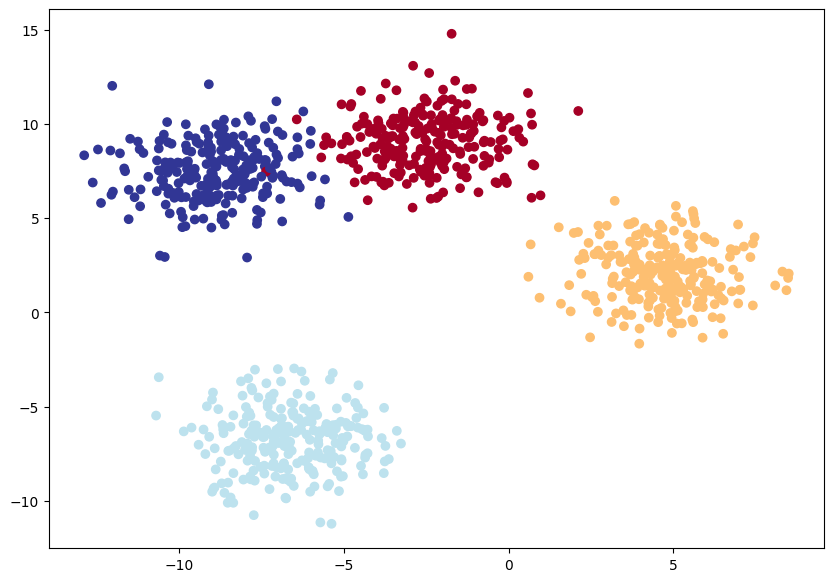

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(x_blob[:,0],x_blob[:,1],c=y_blob, cmap=plt.cm.RdYlBu)


In [ ]:
# Model
model = nn.Sequential(
    nn.Linear(in_features=2 , out_features=8),
    nn.ReLU(),
    nn.Linear(in_features= 8 , out_features= 8 ),
    nn.ReLU(),
    nn.Linear(in_features= 8 , out_features= 4)

)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model.parameters() , lr=0.1)


In [ ]:
# Raw outputs
model.eval()
with torch.inference_mode():
  y_logits= model(X_test)
y_logits[:10]


tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [ ]:
y_pred_probs=torch.softmax(y_logits, dim=1)
y_preds=torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:


# training loop
torch.manual_seed(42)
epochs= 100
for epoch in range(epochs):
  model.train()
  y_logits= model(X_train)
  y_pred= torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss= loss_fn(y_logits , Y_train)
  acc= accuracy_score(Y_train , y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    y_test_logits= model(X_test)
    y_test_preds= torch.softmax(y_test_logits, dim=1).argmax(dim=1)

    test_loss= loss_fn(y_test_logits, Y_test)
    test_acc= accuracy_score(y_test_preds, Y_test)

    if epoch % 10 ==0:
      print(f"Epoch : {epoch}  | loss : {loss:.4f} | acc : {acc:.2f}%  | test loss {test_loss:.4f} | test acc {test_acc:.2f}%")

Epoch : 0  | loss : 1.0636 | acc : 0.55%  | test loss 1.0039 | test acc 0.55%
Epoch : 10  | loss : 0.6210 | acc : 0.97%  | test loss 0.6367 | test acc 0.98%
Epoch : 20  | loss : 0.4061 | acc : 0.99%  | test loss 0.4104 | test acc 1.00%
Epoch : 30  | loss : 0.2362 | acc : 0.99%  | test loss 0.2268 | test acc 0.99%
Epoch : 40  | loss : 0.1044 | acc : 0.99%  | test loss 0.0949 | test acc 0.99%
Epoch : 50  | loss : 0.0640 | acc : 0.99%  | test loss 0.0563 | test acc 0.99%
Epoch : 60  | loss : 0.0497 | acc : 0.99%  | test loss 0.0419 | test acc 0.99%
Epoch : 70  | loss : 0.0424 | acc : 0.99%  | test loss 0.0343 | test acc 0.99%
Epoch : 80  | loss : 0.0380 | acc : 0.99%  | test loss 0.0295 | test acc 0.99%
Epoch : 90  | loss : 0.0350 | acc : 0.99%  | test loss 0.0264 | test acc 0.99%


In [ ]:
# making the prediction
model.eval()
with torch.inference_mode():
  y_logits= model(X_test)
  y_pred_probs= torch.softmax(y_logits , dim=1)
y_pred_probs[:10]

tensor([[1.3158e-03, 9.9868e-01, 1.1725e-06, 5.1754e-07],
        [4.8691e-03, 7.2458e-05, 1.0344e-03, 9.9402e-01],
        [1.3611e-03, 8.3833e-04, 9.9476e-01, 3.0383e-03],
        [4.6540e-03, 9.9492e-01, 3.1196e-04, 1.1070e-04],
        [9.9397e-01, 6.0044e-03, 2.4010e-06, 2.1578e-05],
        [1.3046e-03, 1.1117e-05, 2.9733e-04, 9.9839e-01],
        [2.8462e-03, 2.1055e-03, 9.8807e-01, 6.9819e-03],
        [9.9842e-01, 5.8947e-04, 3.3409e-05, 9.5600e-04],
        [2.7205e-04, 1.4528e-04, 9.9885e-01, 7.2945e-04],
        [9.9829e-01, 1.4306e-03, 1.5493e-05, 2.6443e-04]])

In [ ]:
y_pred = torch.argmax(y_pred_probs , dim=1)
print(Y_test)

y_pred


tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])


tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 0, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

In [ ]:
accuracy_score(Y_test , y_pred)

0.995

In [ ]:
#plotting
def plot_decision_boundary(model, X, y):
    model.eval()

    # Setup prediction boundaries
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Convert to tensor
    X_to_pred = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float)

    with torch.inference_mode():
        y_logits = model(X_to_pred)
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    y_pred = y_pred.reshape(xx.shape).detach().numpy()

    # Plot contour
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Decision Boundary")
    plt.show()

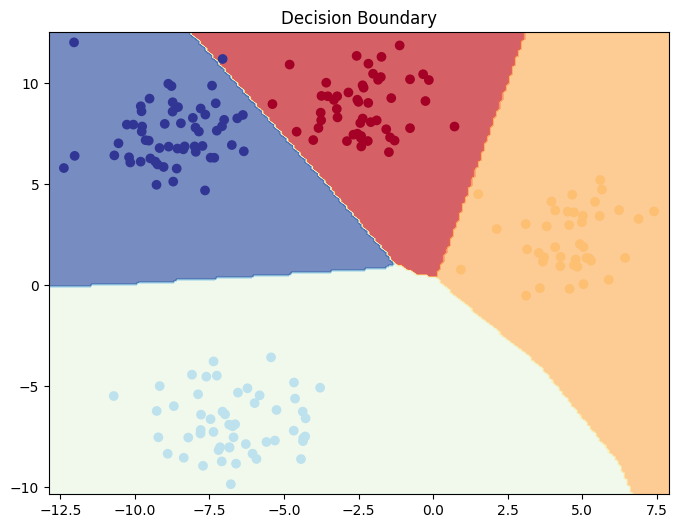

In [ ]:
plot_decision_boundary(model, X_test, Y_test)
